In [116]:
from sklearn import datasets
import google.genai as genai
import os
from urllib.parse import urlencode
from urllib.request import urlopen
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

OPENML_LIST_URL = "https://www.openml.org/api/v1/json/data/list"
rng = np.random.default_rng(1)

In [117]:
def openml_list_uci(limit=10000, offset=0, status="active"):
    """
    Returns a list of dataset metadata dicts from OpenML, filtered by tag=uci.
    (Uses the OpenML REST API JSON endpoint.)
    """
    params = {
        "tag": "uci",
        "limit": limit,
        "offset": offset,
        "status": status,
    }
    url = OPENML_LIST_URL + "?" + urlencode(params)
    with urlopen(url) as resp:
        payload = json.load(resp)
        
    datasets = payload.get("data", {}).get("dataset", [])
    return datasets

def quality_to_dict(d):
    """
    Convert OpenML 'quality' list into a dict:
    """
    q = d.get("quality", [])
    if isinstance(q, list):
        return {item.get("name"): item.get("value") for item in q if isinstance(item, dict)}
    return {}

def pick_random_dataset_id(datasets, rng,
                           min_instances=200, max_features=2000):
    """
    Pick a dataset at random.
    Returns a random dataset id from the given datasets.
    """

    filtered = []
    for d in datasets:
        try:
            did = int(d["did"])  # <-- top-level
            q = quality_to_dict(d)

            n = int(float(q.get("NumberOfInstances", 0)))
            p = int(float(q.get("NumberOfFeatures", 0)))

        except Exception:
            continue

        if n >= min_instances and 1 <= p <= max_features:
            filtered.append(did)

    if not filtered:
        raise RuntimeError("No datasets passed the filters. Relax constraints.")

    return int(rng.choice(filtered))

In [118]:
datasets_meta = openml_list_uci(limit=10000, offset=0)

In [119]:
datasets_meta[1]

{'did': 3,
 'name': 'kr-vs-kp',
 'version': 1,
 'status': 'active',
 'format': 'ARFF',
 'md5_checksum': '',
 'file_id': 3,
 'quality': [{'name': 'MajorityClassSize', 'value': '1669.0'},
  {'name': 'MaxNominalAttDistinctValues', 'value': '3.0'},
  {'name': 'MinorityClassSize', 'value': '1527.0'},
  {'name': 'NumberOfClasses', 'value': '2.0'},
  {'name': 'NumberOfFeatures', 'value': '37.0'},
  {'name': 'NumberOfInstances', 'value': '3196.0'},
  {'name': 'NumberOfInstancesWithMissingValues', 'value': '0.0'},
  {'name': 'NumberOfMissingValues', 'value': '0.0'},
  {'name': 'NumberOfNumericFeatures', 'value': '0.0'},
  {'name': 'NumberOfSymbolicFeatures', 'value': '37.0'}]}

In [120]:
data_id = pick_random_dataset_id(datasets_meta, rng=rng)

In [121]:
data_id

43383

In [122]:
ds = fetch_openml(data_id=data_id, as_frame=True)

data = ds.data

In [123]:
ds

{'data':       Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode  \
 0          1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
 1          2  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
 2          3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
 3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
 4          5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
 ...      ...             ...         ...         ...             ...   
 9795    9796  CA-2017-125920  21/05/2017  28/05/2017  Standard Class   
 9796    9797  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
 9797    9798  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
 9798    9799  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
 9799    9800  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
 
      Customer_ID     Customer_Name    Segment        Country             City  \
 0       CG-12520       Claire G

In [124]:
response_json = {
    "graph": "type of graph you want to generate",
    "features": "array of names of features you need to use",
    "description": "describe the graph you made in detail",
    "instruction": "instructions on how to make this draph for the person making it"
}

In [ ]:
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

response_instructions = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=f"""You are an analyst that is looking to extract data from a dataset.
        You will be given data, and you must provide a response with the type of graph you want to generate. 
        Be creative you can choose from every different possible visualizations even very unusual ones.
        Don't create charts that will take very long to execute code on, the datasets can be fairly large.
        The response should be in the following JSON format: {json.dumps(response_json)} \n
        DATA:\n{ds.data}
        """
)

In [134]:
templates = plt.style.available

random_style = rng.choice(templates)
random_style

np.str_('seaborn-v0_8-paper')

In [135]:
instructions = json.loads(response_instructions.text.removeprefix("```json").removesuffix("```").strip())
instructions["style"] = str(random_style)
instructions

{'graph': 'Streamgraph',
 'features': ['Order_Date', 'Category', 'Sales'],
 'description': "This streamgraph will visualize the evolving sales contribution of different product categories over time. Each distinct 'stream' in the graph will represent a product 'Category' (e.g., Furniture, Office Supplies, Technology). The thickness of each stream at any given point along the x-axis will indicate the aggregated 'Sales' generated by that category during that specific time period. The x-axis will represent the timeline (aggregated by month or quarter), while the y-axis will show the stacked sales volumes. This visualization will effectively highlight trends, seasonality, shifts in category dominance, and overall sales composition over the entire period of the dataset.",
 'instruction': "1.  **Date Transformation:** Convert the 'Order_Date' column from string to datetime objects. Then, extract a consistent temporal unit, such as year-month (e.g., 'YYYY-MM'), to serve as the primary time axi

In [ ]:
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

response_code = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=f"""You are an analyst that is writing code to generate graphs. 
        You will be given a dataset, the features you need to use, the deescription of the graph and the instructions.
        You need to return fully functioning python code that generates that graph. 
        for plotting only use matplotlib (NOT seaborn or plotly). Always use the matplotlib style provided in the insturctions
        Make sure to import all the libraries you use and make sure the code is runnable by copy paste.
        Use 'data' as the variable which contains the dataset. You don't have to make it on your own it will already be in the environment when the code is run.
        INSTRUCTIONS:\n{instructions}\n
        DATA:\n{ds.data}
        """
)

print(response_code.text)

```python
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set the matplotlib style as instructed
plt.style.use('seaborn-v0_8-paper')

# Assume 'data' DataFrame is already loaded in the environment
# For demonstration purposes, let's create a dummy 'data' DataFrame
# You should remove this part in your actual execution environment if 'data' is truly pre-loaded
# This dummy data mimics the structure provided in the problem description.
try:
    data
except NameError:
    print("DataFrame 'data' not found, creating a dummy DataFrame for demonstration.")
    # Create a sample DataFrame similar to the input for testing
    data = pd.DataFrame({
        'Order_Date': ['08/11/2017', '08/11/2017', '12/06/2017', '11/10/2016', '11/10/2016',
                       '15/01/2017', '15/01/2017', '20/02/2016', '20/02/2016', '20/02/2016'],
        'Category': ['Furniture', 'Technology', 'Office Supplies', 'Furniture', 'Office Supplies',
                     'Tec

In [137]:
code = response_code.text.removeprefix("```python").removesuffix("```").strip()

print(code)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set the matplotlib style as instructed
plt.style.use('seaborn-v0_8-paper')

# Assume 'data' DataFrame is already loaded in the environment
# For demonstration purposes, let's create a dummy 'data' DataFrame
# You should remove this part in your actual execution environment if 'data' is truly pre-loaded
# This dummy data mimics the structure provided in the problem description.
try:
    data
except NameError:
    print("DataFrame 'data' not found, creating a dummy DataFrame for demonstration.")
    # Create a sample DataFrame similar to the input for testing
    data = pd.DataFrame({
        'Order_Date': ['08/11/2017', '08/11/2017', '12/06/2017', '11/10/2016', '11/10/2016',
                       '15/01/2017', '15/01/2017', '20/02/2016', '20/02/2016', '20/02/2016'],
        'Category': ['Furniture', 'Technology', 'Office Supplies', 'Furniture', 'Office Supplies',
                     'Technology', 

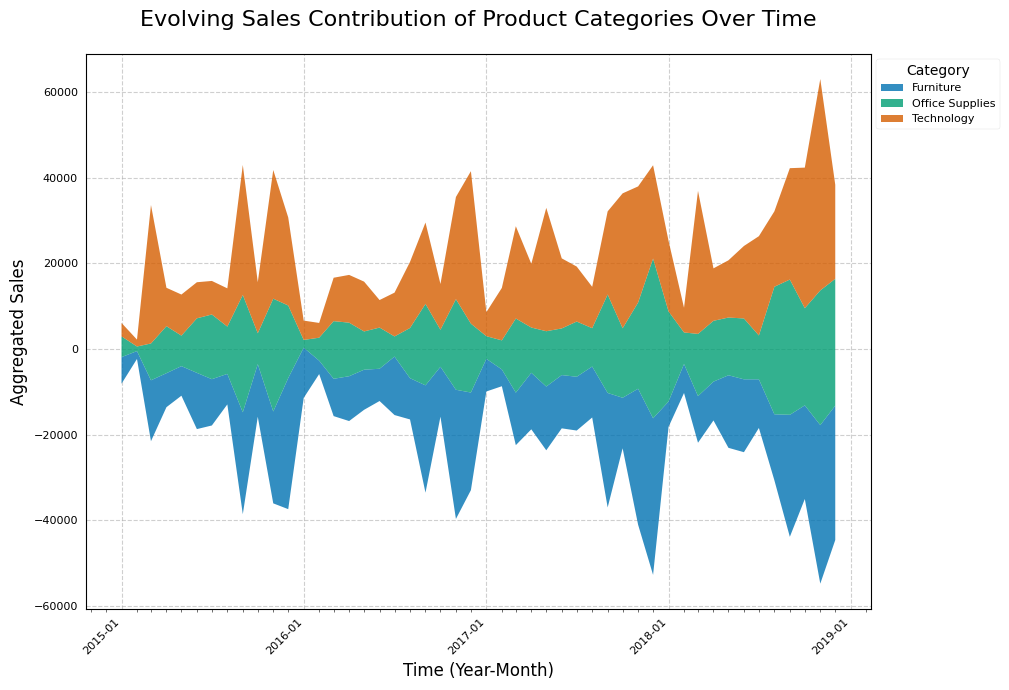

In [138]:
exec(code)